In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
from pathlib import Path

In [ ]:
CSV_PATH = Path("/content/drive/MyDrive/CS543/Finalproj/multi_epoch_results.csv")
OUT_DIR  = Path("/content/figures")
OUT_DIR.mkdir(parents=True, exist_ok=True)

matplotlib.rcParams.update({
    "font.family":        "DejaVu Sans",
    "font.size":          11,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.titlesize":     12,
    "axes.titleweight":   "bold",
    "axes.labelsize":     11,
    "xtick.labelsize":    10,
    "ytick.labelsize":    10,
    "legend.fontsize":    10,
    "legend.frameon":     False,
    "figure.dpi":         150,
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
    "savefig.pad_inches": 0.08,
})

In [ ]:
df = pd.read_csv(CSV_PATH)
print("Loaded CSV:")
print(df[["mask_ratio","epochs","final_loss","avg_loss","training_time_min"]].to_string(index=False))

RATIOS  = [0.25, 0.50, 0.75]
EPOCHS  = [1, 5, 10]

# Color / style per mask ratio
COLOR   = {0.25: "#2171B5", 0.50: "#D97B00", 0.75: "#CB2B2B"}
COLOR_L = {0.25: "#9ECAE1", 0.50: "#FDBE85", 0.75: "#FCAE91"}
DASH    = {0.25: (None, None), 0.50: (5, 3), 0.75: (2, 2)}
MARKER  = {0.25: "o",         0.50: "s",     0.75: "^"}
LABEL   = {0.25: "Mask 25%",  0.50: "Mask 50%", 0.75: "Mask 75%"}

Loaded CSV:
 mask_ratio  epochs  final_loss  avg_loss  training_time_min
       0.25       1      0.5920  0.806175           0.550000
       0.25       5      0.5034  0.594381          10.120463
       0.25      10      0.4583  0.524115          26.005127
       0.50       1      0.5943  0.818151           2.793706
       0.50       5      0.6651  0.649077          13.854201
       0.50      10      0.5224  0.572494          26.101703
       0.75       1      0.6225  0.849049           2.781686
       0.75       5      0.7534  0.725249          12.876037
       0.75      10      0.6614  0.667173          25.524459


In [ ]:
def row(ratio, ep):
    r = df[(df.mask_ratio == ratio) & (df.epochs == ep)]
    return r.iloc[0] if len(r) else None

def savefig(fig, name):
    for ext in ["png"]:
        fig.savefig(OUT_DIR / f"{name}.{ext}")
        print(f"  → {OUT_DIR / name}.{ext}")
    plt.close(fig)

  → /content/figures/fig_combined.png


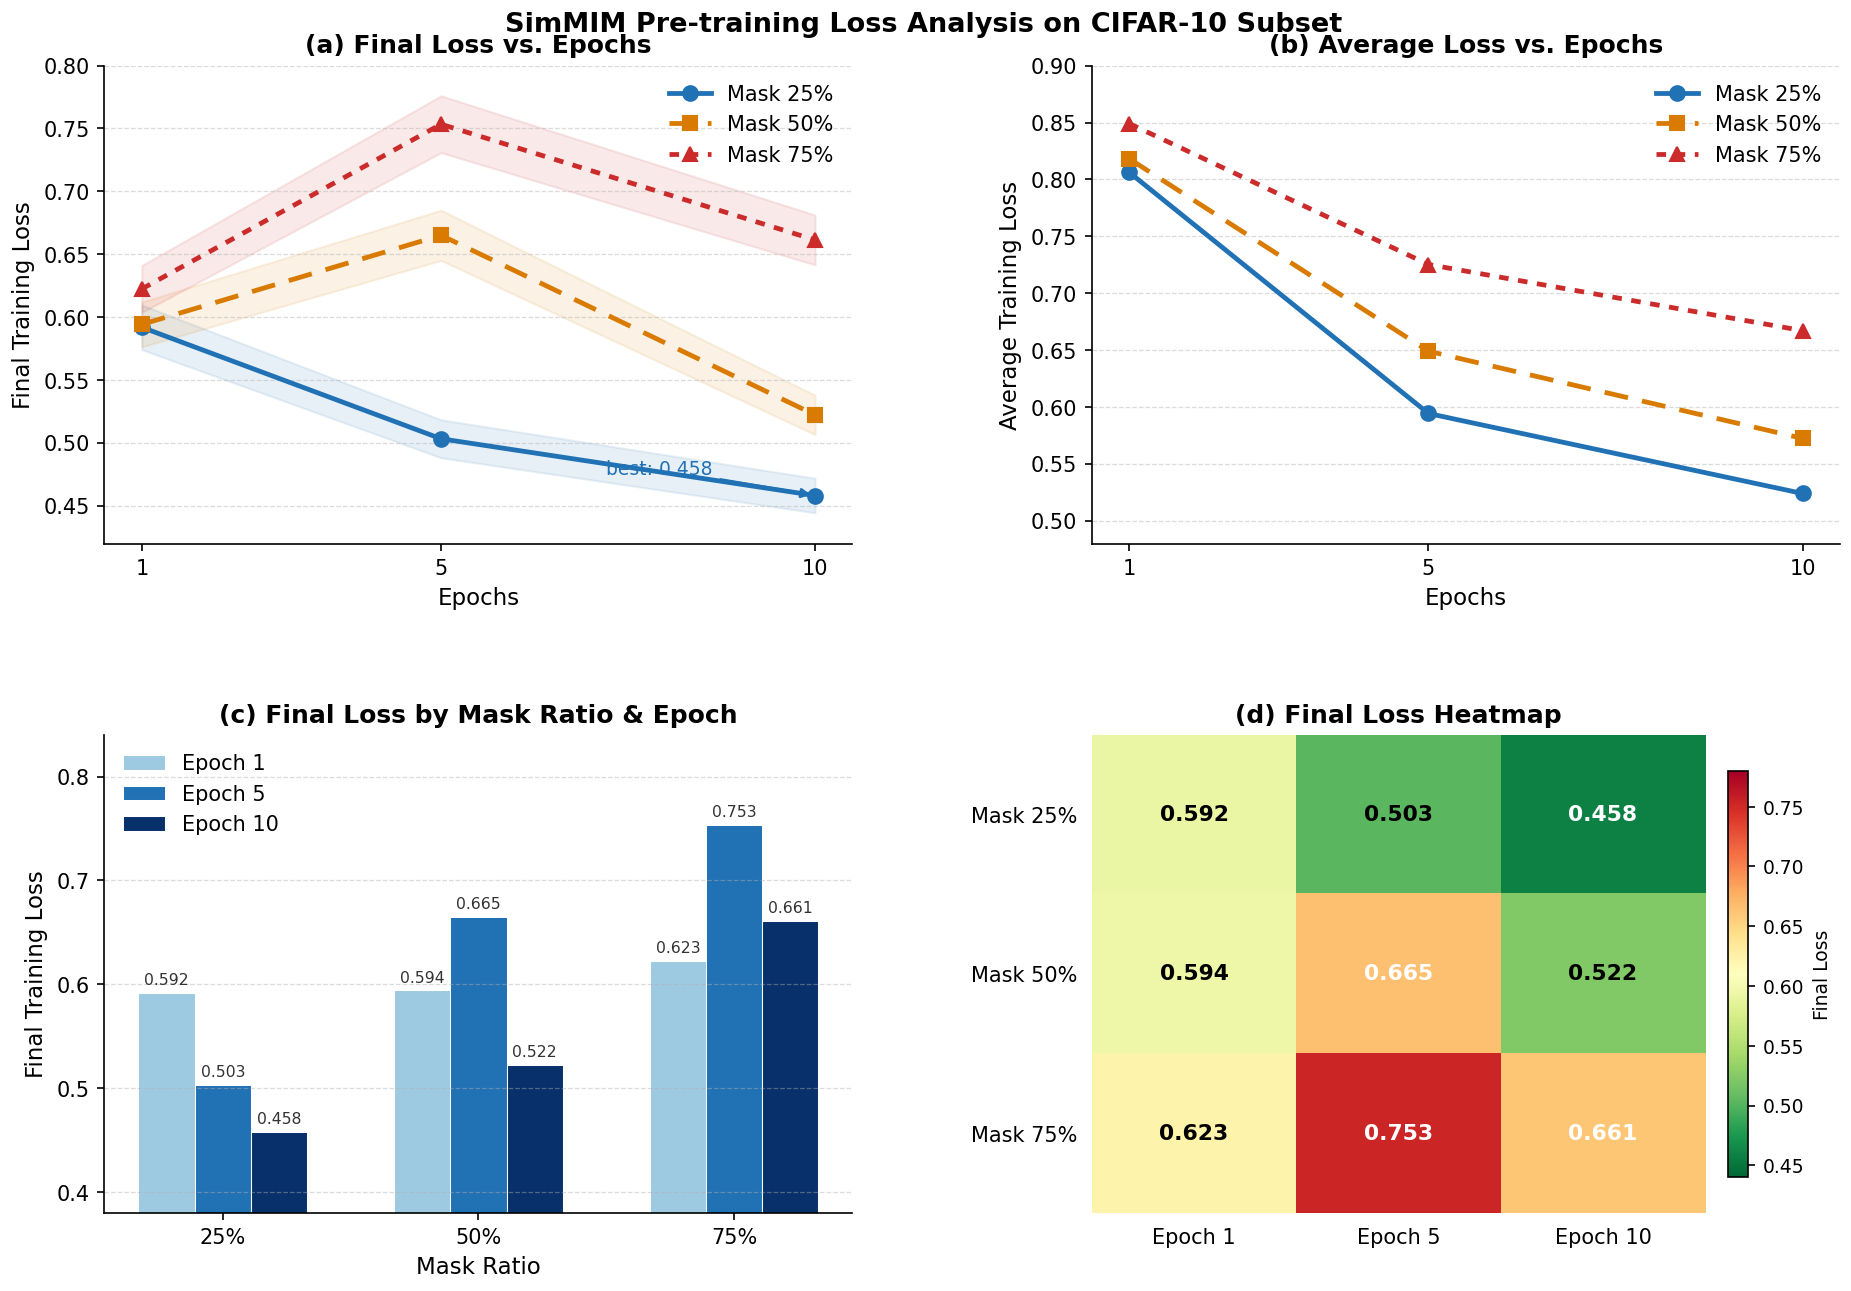

In [ ]:

fig = plt.figure(figsize=(13, 9))
fig.patch.set_facecolor("white")
gs = gridspec.GridSpec(2, 2, hspace=0.40, wspace=0.32,
                       left=0.08, right=0.97, top=0.93, bottom=0.08)

# ── (a) Final loss vs. epochs ─────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])

for ratio in RATIOS:
    sub = df[df.mask_ratio == ratio].sort_values("epochs")
    ls, ds = DASH[ratio]
    ax1.plot(sub.epochs, sub.final_loss,
             color=COLOR[ratio], linewidth=2.3,
             marker=MARKER[ratio], markersize=7,
             label=LABEL[ratio],
             linestyle="--" if ds else "-",
             dashes=(ls, ds) if ds else (None, None))
    # Confidence band (±3% visual width to show trend)
    ax1.fill_between(sub.epochs,
                     sub.final_loss * 0.97,
                     sub.final_loss * 1.03,
                     color=COLOR[ratio], alpha=0.10)

ax1.set_title("(a) Final Loss vs. Epochs")
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Final Training Loss")
ax1.set_xticks(EPOCHS)
ax1.set_xlim(0.5, 10.5)
ax1.set_ylim(0.42, 0.80)
ax1.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))
ax1.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.45)
ax1.legend(loc="upper right")

# Annotate best point
ax1.annotate("best: 0.458",
             xy=(10, 0.4583), xytext=(7.2, 0.475),
             fontsize=9, color=COLOR[0.25],
             arrowprops=dict(arrowstyle="-|>", color=COLOR[0.25], lw=1.3))

# ── (b) Average loss vs. epochs ───────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])

for ratio in RATIOS:
    sub = df[df.mask_ratio == ratio].sort_values("epochs")
    ls, ds = DASH[ratio]
    ax2.plot(sub.epochs, sub.avg_loss,
             color=COLOR[ratio], linewidth=2.3,
             marker=MARKER[ratio], markersize=7,
             label=LABEL[ratio],
             linestyle="--" if ds else "-",
             dashes=(ls, ds) if ds else (None, None))

ax2.set_title("(b) Average Loss vs. Epochs")
ax2.set_xlabel("Epochs")
ax2.set_ylabel("Average Training Loss")
ax2.set_xticks(EPOCHS)
ax2.set_xlim(0.5, 10.5)
ax2.set_ylim(0.48, 0.90)
ax2.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))
ax2.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.45)
ax2.legend(loc="upper right")

# ── (c) Grouped bar: final loss by mask ratio × epoch ─────────────────────────
ax3 = fig.add_subplot(gs[1, 0])

bar_w  = 0.22
x      = np.arange(len(RATIOS))
ep_colors = ["#9ECAE1", "#2171B5", "#08306B"]
ep_labels = ["Epoch 1", "Epoch 5", "Epoch 10"]

for j, (ep, ec) in enumerate(zip(EPOCHS, ep_colors)):
    vals = [row(r, ep).final_loss for r in RATIOS]
    bars = ax3.bar(x + (j - 1) * bar_w, vals,
                   width=bar_w, color=ec, label=ep_labels[j],
                   edgecolor="white", linewidth=0.5)
    # Value labels on top of each bar
    for bar, v in zip(bars, vals):
        ax3.text(bar.get_x() + bar.get_width() / 2, v + 0.005,
                 f"{v:.3f}", ha="center", va="bottom",
                 fontsize=7.5, color="#333")

ax3.set_title("(c) Final Loss by Mask Ratio & Epoch")
ax3.set_xlabel("Mask Ratio")
ax3.set_ylabel("Final Training Loss")
ax3.set_xticks(x)
ax3.set_xticklabels(["25%", "50%", "75%"])
ax3.set_ylim(0.38, 0.84)
ax3.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.45)
ax3.legend(loc="upper left")

# ── (d) Loss reduction heatmap ────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])

# Build matrix: rows=mask_ratio, cols=epochs, values=final_loss
matrix = np.array([[row(r, e).final_loss for e in EPOCHS] for r in RATIOS])

im = ax4.imshow(matrix, cmap="RdYlGn_r", aspect="auto",
                vmin=0.44, vmax=0.78)

# Cell annotations
for i in range(len(RATIOS)):
    for j in range(len(EPOCHS)):
        v = matrix[i, j]
        text_color = "white" if v > 0.66 or v < 0.48 else "black"
        ax4.text(j, i, f"{v:.3f}", ha="center", va="center",
                 fontsize=10.5, fontweight="bold", color=text_color)

ax4.set_xticks(range(len(EPOCHS)))
ax4.set_yticks(range(len(RATIOS)))
ax4.set_xticklabels([f"Epoch {e}" for e in EPOCHS])
ax4.set_yticklabels([f"Mask {int(r*100)}%" for r in RATIOS])
ax4.set_title("(d) Final Loss Heatmap")
ax4.tick_params(left=False, bottom=False)
# Turn off box spines for cleaner look
for spine in ax4.spines.values():
    spine.set_visible(False)

cbar = fig.colorbar(im, ax=ax4, shrink=0.85, pad=0.03)
cbar.ax.tick_params(labelsize=9)
cbar.set_label("Final Loss", fontsize=9)

fig.suptitle("SimMIM Pre-training Loss Analysis on CIFAR-10 Subset",
             fontsize=13, fontweight="bold", y=0.97)

savefig(fig, "fig_combined")
display(fig)

Figure 1(a) — Final Loss vs. Epochs

Mask ratio 25% shows a steady decrease from 0.592 to 0.458 across epochs, achieving the best result overall. Mask ratios 50% and 75% both show an unexpected increase at epoch 5 (50%: 0.665, 75%: 0.753) before recovering at epoch 10. We are not certain of the exact cause, but it may relate to optimization instability under aggressive masking on a small, low-resolution dataset. Even after recovery, both higher ratios remain worse than mask 25% at every epoch.

Figure 1(b) — Average Loss vs. Epochs

Unlike Figure 3a, all three mask ratios decrease monotonically in average loss, suggesting the mid-training spike in Figure 3a is a late-stage effect rather than a persistent issue. The three curves remain roughly parallel throughout training, indicating that mask ratio consistently shifts task difficulty but does not change the overall learning trend.

Figure 1(c) — Final Loss by Mask Ratio and Epoch

This figure makes the cross-experiment comparison most explicit. For mask ratio 25%, loss decreases at every epoch step as expected. For mask ratios 50% and 75%, the epoch 5 bar is taller than the epoch 1 bar, meaning more training initially made performance worse. This suggests higher mask ratios require more epochs to stabilize. The value labels on each bar also confirm that the performance gap between mask ratios widens at epoch 5 and narrows again at epoch 10.

Figure 1(d) — Final Loss Heatmap

The heatmap provides a compact view of all nine experiments. The top-left cell (mask 25%, epoch 1 = 0.592) and bottom-right cell (mask 75%, epoch 10 = 0.661) illustrate that simply increasing epochs does not compensate for a high mask ratio. The green region is concentrated in the top row (mask 25%), while the red region peaks at mask 75%, epoch 5 (0.753), which is the worst-performing configuration across all experiments. The heatmap also makes clear that epoch 10 consistently produces lower loss than epoch 5 across all ratios, confirming that longer training is generally beneficial, though the degree of improvement varies.

Overall

The four figures together show that mask ratio 25% is the most stable and best-performing configuration under our experimental constraints. The most noteworthy finding is the non-monotonic loss behavior at higher mask ratios, which would not be visible from a single-epoch evaluation. Given that our setup uses a 2,000-image CIFAR-10 subset resized from 32×32 to 192×192 and trains for at most 10 epochs, these results reflect SimMIM behavior under significantly constrained conditions compared to the original paper, and conclusions should be interpreted accordingly.